In [1]:
from utils_00 import *
# exec(open('c00_utils.py').read())

pn.extension()  # 启用 Jupyter 支持
pd.set_option('expand_frame_repr', False)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', 100)

In [2]:
native_exchange_data_dir = os.path.join(base_dir, "Native_Exchange_Data")
temporary_experimental_data_dir = os.path.join(base_dir, "Temporary_Experimental_Data")
pro = ts.pro_api(secret_dict['tushare']['api_key'])

def get_exchange_variety_map():
    # 交易所日历路径 NED_dimension_exchange_calendar_path
    NED_dimension_exchange_calendar_path = os.path.join(native_exchange_data_dir, 'dimension_exchange_calendar.csv')
    dimension_exchange_calendar = pd.read_csv(NED_dimension_exchange_calendar_path, dtype = {'date': str})

    # 获取 交易所-品种 表单
    exchange_list = [col for col in dimension_exchange_calendar.columns if col != 'date'] # 交易所列表
    map_list = []
    for exchange in exchange_list:

        exchange_variety_map = pd.DataFrame()
        for attempt in range(3):
            try:
                exchange_variety_map = pro.fut_basic(exchange = exchange, fut_type = "1", fields = ["fut_code"])
                break
            except Exception as e:
                print(f"第 {attempt + 1} 次获取 {exchange} 品种信息失败: {e}")

        exchange_variety_map = exchange_variety_map.drop_duplicates()
        exchange_variety_map["exchange"] = exchange
        map_list.append(exchange_variety_map)

    exchange_variety_map = pd.concat(map_list, ignore_index = True)
    exchange_variety_map = exchange_variety_map.groupby('exchange')['fut_code'].apply(list)
    exchange_variety_map = exchange_variety_map.to_dict()
    return exchange_variety_map

if __name__ == '__main__':
    exchange_variety_map = get_exchange_variety_map()
    exchange_variety_map.pop("CZCE")
    exchange_variety_map.pop("DCE")
    print(exchange_variety_map)

{'CFFEX': ['T', 'TF', 'IF', 'IM', 'IC', 'IH', 'TS', 'TL'], 'GFEX': ['LC', 'SI', 'PS', 'PD', 'PT'], 'INE': ['NR', 'SC', 'LU', 'BC', 'SCTAS', 'EC'], 'SHFE': ['AO', 'NI', 'AL', 'HC', 'BU', 'RU', 'FU', 'CU', 'AG', 'ZN', 'AU', 'PB', 'SS', 'RB', 'SN', 'WR', 'SP', 'BR', 'AD', 'OP']}


In [3]:
exchange = None
variety = None

if __name__ == '__main__':
    # 交易所选择组件
    exchange_radio = widgets.RadioButtons(
        options = list(exchange_variety_map.keys()),
        description = '交易所选择 exchange:',
        layout = {'width': '400px'}
    )

    # 品种选择组件（初始禁用）
    species_toggle = widgets.ToggleButtons(
        options = [],
        description = '品种选择 variety:',
        disabled = True,
        button_style = '',
        style = {'button_width': 'auto'},
        layout = widgets.Layout(width = '600px'),
    )

    # 输出提示区域
    out = widgets.Textarea(
        value = '请先选择交易所，然后选择品种',
        layout = {'width': '400px', 'height': '50px'},
        disabled = True
    )

    display(widgets.VBox([exchange_radio, species_toggle, out]))

    def on_exchange_change(change):
        """当交易所改变时，更新可选品种"""
        global exchange
        if change['name'] == 'value':
            exchange = change['new']
            varieties = exchange_variety_map.get(exchange, [])
            species_toggle.options = sorted(varieties)
            species_toggle.disabled = len(varieties) == 0
            if varieties:
                species_toggle.value = varieties[0]  # 默认选第一个
                out.value = f'已选择交易所：{exchange}，请选择品种'
            else:
                out.value = f'交易所 {exchange} 无可用品种'

    def on_species_change(change):
        """当品种改变时，记录到全局变量"""
        global variety
        if change['name'] == 'value' and species_toggle.options:
            variety = change['new']
            out.value = f'已选择交易所 exchange: {exchange}\n已选择品种 variety: {variety}'

    # 绑定事件 ["SCTAS", "SI", "FU", "AU", "SS", "WR"]
    exchange_radio.observe(on_exchange_change, names = 'value')
    species_toggle.observe(on_species_change, names = 'value')

In [4]:
dataset_range_boundary = ""  # 选择的时间范围边界字符串

if __name__ == '__main__':

    # 临时实验数据品种文件夹路径 TED_variety_path
    TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))
    dataset_range = os.listdir(TED_variety_path)
    dataset_range = sorted(dataset_range)

    dataset_range_buttons = []  # 创建数据集范围边界按钮容器
    for range_file in dataset_range:  # 为每个范围文件创建按钮
        btn = widgets.Button(
            description = range_file,
            layout = {'width': '530px', 'height': '25px'},  # 宽度较大以显示完整文件名
            button_style = ''
        )
        dataset_range_buttons.append(btn)

    dataset_range_button_column = widgets.VBox(dataset_range_buttons) # Horizontal Box & Vertical Box

    # 输出显示区域
    range_display_output = widgets.Textarea(
        value = 'dataset_range_boundary: 未选择',
        layout = {'width': '530px', 'height': '30px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([
        widgets.Label('数据集范围边界 dataset_range_boundary:'),
        dataset_range_button_column,
        range_display_output
    ]))

    def update_range_display():
        """更新显示区域"""
        global dataset_range_boundary
        range_display_output.value = f'dataset_range_boundary: {dataset_range_boundary}'

    def set_dataset_range_boundary(range_file):
        """设置数据集范围边界"""
        global dataset_range_boundary
        dataset_range_boundary = range_file
        update_range_display()

    # 事件处理函数
    def on_dataset_range_button_click(btn):
        """数据集范围按钮 点击事件"""
        set_dataset_range_boundary(btn.description)

    # 绑定事件
    for btn in dataset_range_buttons:
        btn.on_click(on_dataset_range_button_click)

    # 初始化
    update_range_display()

In [5]:
tick_granularity = 0  # 采样颗粒度 全局变量
resample_axis = None  # 采样轴 全局变量

if __name__ == '__main__':

    # 创建 tick_granularity 输入框组件
    tick_granularity_input = widgets.IntText(
        value = 0,
        description = 'tick_granularity:',
        layout = {'width': '250px', 'height': '25px'},
        style = {'description_width': '90px'},
        continuous_update = False
    )

    # 创建 tick_granularity 按钮容器
    granularity_buttons = []
    for i in [i for i in range(0, 181, 15)]:
        btn = widgets.Button(
            description = str(i),
            layout = {'width': '45px', 'height': '25px'}
        )
        btn.value = i
        granularity_buttons.append(btn)
    granularity_button_row = widgets.HBox(granularity_buttons)

    # tick_granularity 输出显示区域
    granularity_out = widgets.Textarea(
        value = '当前 tick_granularity: 0',
        layout = {'width': '400px', 'height': '30px'},
        disabled = True
    )

    # 创建 resample_axis 按钮
    axis_buttons = []
    axis_options = ['time_axis_data', 'volume_axis_data', 'money_axis_data']  # 重采样刻度选项
    for option in axis_options:
        btn = widgets.Button(
            description = option,
            layout = {'width': '135px', 'height': '25px'}
        )
        btn.value = option
        axis_buttons.append(btn)
    axis_button_row = widgets.HBox(axis_buttons)

    # resample_axis 显示区域
    axis_out = widgets.Textarea(
        value = '当前 resample_axis: None',
        layout = {'width': '400px', 'height': '30px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([tick_granularity_input, granularity_button_row, granularity_out, axis_button_row, axis_out]))

    def update_display(value):
        """更新显示"""
        global tick_granularity
        tick_granularity = value
        granularity_out.value = f'当前 tick_granularity: {tick_granularity}'
        tick_granularity_input.value = value

    def update_axis_display(value):
        """更新 resample_axis 显示"""
        global resample_axis
        resample_axis = value
        axis_out.value = f'当前 resample_axis: {resample_axis}'

    def on_input_change(change):
        """当输入框值改变时"""
        if change['name'] == 'value':
            new_value = change['new']
            if 0 <= new_value <= 600:
                update_display(new_value)
            else:
                tick_granularity_input.value = tick_granularity  # 恢复原值

    def on_button_click(btn):
        """当按钮点击时"""
        new_value = btn.value
        update_display(new_value)

    def on_axis_button_click(btn):
        """当 resample_axis 按钮点击时"""
        new_value = btn.value
        update_axis_display(new_value)

    # 绑定输入框事件
    tick_granularity_input.observe(on_input_change, names ='value')

    # 绑定所有按钮事件
    for btn in granularity_buttons:
        btn.on_click(on_button_click)

    # 绑定 resample_axis 按钮事件
    for btn in axis_buttons:
        btn.on_click(on_axis_button_click)

In [7]:
lookback_months = 0  # 回溯月份数 全局变量
split_index = None  # 切割点 index 全局变量
split_time_str = None  # 切割时间字符串 全局变量

if __name__ == '__main__':

    TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))  # 临时实验数据品种文件夹路径 TED_variety_path
    dataset_range_boundary_path = os.path.join(TED_variety_path, dataset_range_boundary)  # 时间范围文件夹路径 dataset_range_boundary_path
    tick_granularity_resample_path = os.path.join(dataset_range_boundary_path, f'tick_granularity_{tick_granularity}')  # 采样刻度文件路径 tick_granularity_resample_path
    resample_axis_data_path = os.path.join(tick_granularity_resample_path, resample_axis)  # 驱动轴数据文件路径 resample_axis_data_path

    tick_type_dict = {
        'time_axis_data': 'Nrow',
        'volume_axis_data': 'volume',
        'money_axis_data': 'money'
    }
    if resample_axis in tick_type_dict.keys():
        tick_type = tick_type_dict[resample_axis]
    else: raise ValueError

    # 主力片段拼接重采样时间索引路径 main_continuous_resampled_date_index_path
    main_continuous_resampled_date_index_path = os.path.join(resample_axis_data_path, rf"main_continuous_{tick_type}_date_index.csv")
    main_continuous_resampled_date_index = pd.read_csv(main_continuous_resampled_date_index_path, dtype = {'date': str})

    # 创建 lookback_months 输入框组件
    lookback_months_input = widgets.IntText(
        value = 0,
        description = 'lookback_months:',
        layout = {'width': '250px', 'height': '25px'},
        style = {'description_width': '100px'},
        continuous_update = False
    )

    # 创建 lookback_months 按钮容器（1~24）
    months_buttons = []
    for i in range(1, 25):
        btn = widgets.Button(
            description = str(i),
            layout = {'width': '45px', 'height': '25px'}
        )
        btn.value = i
        months_buttons.append(btn)
    first_row = widgets.HBox(months_buttons[:12])   # 前12个按钮
    second_row = widgets.HBox(months_buttons[12:])  # 后12个按钮
    months_button_row = widgets.VBox([first_row, second_row])

    # 输出显示区域：包含回溯月份、切割index、切割时间
    split_info_out = widgets.Textarea(
        value = '当前 lookback_months: \nsplit_index: None \nsplit_time_str: None',
        layout = {'width': '600px', 'height': '60px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([lookback_months_input, months_button_row, split_info_out]))

    def update_split_info():
        """根据 lookback_months 和 main_continuous_resampled_date_index 计算并更新 split_index 与 split_time_str"""
        global lookback_months, split_index, split_time_str

        if lookback_months <= 0 or main_continuous_resampled_date_index.empty:
            split_index = None
            split_time_str = None
        else:
            # 获取最后一行的时间字符串并转换为 datetime
            last_time_str = main_continuous_resampled_date_index['date'].iloc[-1]
            last_dt = pd.to_datetime(last_time_str)

            # 回溯指定月份数（注意：pandas 的 DateOffset 支持月份偏移）
            target_dt = last_dt - pd.DateOffset(months=lookback_months)

            # 找到最接近但不大于 target_dt 的行的 index
            date_series = pd.to_datetime(main_continuous_resampled_date_index['date'])
            valid_mask = date_series <= target_dt
            if valid_mask.any():
                split_index = valid_mask[::-1].idxmax()  # 最后一个满足条件的 index
                split_time_str = main_continuous_resampled_date_index['date'].iloc[split_index]
            else:
                split_index = 0
                split_time_str = main_continuous_resampled_date_index['date'].iloc[0]

        # 更新显示
        split_info_out.value = f'当前 lookback_months: {lookback_months} \nsplit_index: {split_index} \nsplit_time_str: {split_time_str}'

    def on_months_input_change(change):
        """当输入框值改变时"""
        if change['name'] == 'value':
            new_value = change['new']
            if 0 <= new_value <= 24:
                global lookback_months
                lookback_months = new_value
                lookback_months_input.value = new_value
                update_split_info()
            else:
                lookback_months_input.value = lookback_months  # 恢复原值

    def on_months_button_click(btn):
        """当按钮点击时"""
        global lookback_months
        lookback_months = btn.value
        lookback_months_input.value = lookback_months
        update_split_info()

    # 绑定输入框事件
    lookback_months_input.observe(on_months_input_change, names='value')

    # 绑定所有按钮事件
    for btn in months_buttons:
        btn.on_click(on_months_button_click)

    # 初始化显示
    update_split_info()

In [8]:
# 临时实验数据品种文件夹路径 TED_variety_path
TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))

# 时间范围文件夹路径 dataset_range_boundary_path
dataset_range_boundary_path = os.path.join(TED_variety_path, dataset_range_boundary)

# 采样刻度文件路径 tick_granularity_resample_path
tick_granularity_resample_path = os.path.join(dataset_range_boundary_path, f'tick_granularity_{tick_granularity}')

# 驱动轴数据文件路径 resample_axis_data_path
resample_axis_data_path = os.path.join(tick_granularity_resample_path, resample_axis)

tick_type_dict = {
    'time_axis_data': 'Nrow',
    'volume_axis_data': 'volume',
    'money_axis_data': 'money'
}
if resample_axis in tick_type_dict.keys():
    tick_type = tick_type_dict[resample_axis]
else: raise ValueError

# 主力片段拼接重采样时间索引路径 main_continuous_resampled_date_index_path
main_continuous_resampled_date_index_path = os.path.join(resample_axis_data_path, f'main_continuous_{tick_type}_date_index.csv')
main_continuous_resampled_date_index = pd.read_csv(main_continuous_resampled_date_index_path, dtype = {'date': str})

# 期限结构拟合文件路径 Nelson_Siegel_Svensson_path
Nelson_Siegel_Svensson_path = os.path.join(resample_axis_data_path, f'Nelson_Siegel_Svensson')
os.makedirs(Nelson_Siegel_Svensson_path, exist_ok = True)

# NSS四因子模型超参数组合路径 lambda_combination_dataframe_path
lambda_combination_dataframe_path = os.path.join(Nelson_Siegel_Svensson_path, 'lambda_combination_dataframe.csv')
lambda_combination_dataframe = pd.read_csv(lambda_combination_dataframe_path)

# NSS四因子热启动数据网格搜索结果路径 iterative_combination_row_error_path
iterative_combination_row_error_path = os.path.join(Nelson_Siegel_Svensson_path, 'iterative_combination_row_error.csv')
iterative_combination_row_error = pd.read_csv(iterative_combination_row_error_path)

In [9]:
def Mean_Error_Heatmap_by_Lambda_Combinations_plot(
    iterative_combination_row_error: pd.DataFrame,
    lambda_combination_dataframe: pd.DataFrame
):
    iterative_combination_error_mean = iterative_combination_row_error.mean()  # 计算表二每列的均值
    iterative_combination_error_mean = pd.DataFrame({  # 将均值结果转换为 DataFrame
        'lambda_combination_id': iterative_combination_error_mean.index,
        'mean_error': iterative_combination_error_mean.values
    })

    merged_data = pd.merge(  # 将均值与表一合并
        lambda_combination_dataframe,
        iterative_combination_error_mean,
        on = 'lambda_combination_id',
        how = 'left'
    )

    # 重塑数据为热力图需要的矩阵格式
    # 获取 lambda_1 和 lambda_2 的唯一值并排序
    lambda_1_vals = sorted(merged_data['lambda_1'].unique())
    lambda_2_vals = sorted(merged_data['lambda_2_ratio'].unique())
    heatmap_matrix = merged_data.pivot(
        index = 'lambda_1',
        columns = 'lambda_2_ratio',
        values = 'mean_error'
    )

    plt.figure(figsize = (12, 10))
    from matplotlib.colors import LogNorm
    sns.heatmap(
        heatmap_matrix,

        xticklabels = [f"{x:.5f}" for x in lambda_2_vals],
        yticklabels = [f"{x:.5f}" for x in lambda_1_vals],
        # xticklabels = lambda_2_vals,
        # yticklabels = lambda_1_vals,

        cmap = 'viridis',  #  'viridis'  'coolwarm'  'YlOrRd'  'plasma'  'gray'
        norm = LogNorm(  # 对数映射的色带
            vmin = heatmap_matrix.values.min(),
            vmax = heatmap_matrix.values.max()),

        annot = True,  # 是否显示数值
        annot_kws = {"size": 6.5},  # 显式数值的字体大小
        fmt = '.2f',
    )
    plt.title('Mean Error Heatmap by Lambda Combinations', fontsize = 16, fontweight = 'bold')
    plt.xlabel('lambda_2_ratio', fontsize = 14, fontweight = 'bold')
    plt.ylabel('lambda_1', fontsize = 14, fontweight = 'bold')
    plt.tight_layout()
    plt.show()

    print(f"Lambda 1 的范围: {merged_data['lambda_1'].min()} 到 {merged_data['lambda_1'].max()}")
    print(f"Lambda 2 ratio 的范围: {merged_data['lambda_2_ratio'].min()} 到 {merged_data['lambda_2_ratio'].max()}")
    print(f"平均误差的范围: {merged_data['mean_error'].min()} 到 {merged_data['mean_error'].max()}")
    print(f"最小误差组合:")
    best_idx = merged_data['mean_error'].idxmin()
    print(f"  ID: {merged_data.loc[best_idx, 'lambda_combination_id']}")
    print(f"  Lambda 1: {merged_data.loc[best_idx, 'lambda_1']:.12f}")
    print(f"  Lambda 2 ratio: {merged_data.loc[best_idx, 'lambda_2_ratio']:.12f}")
    print(f"  平均误差: {merged_data.loc[best_idx, 'mean_error']}")

In [32]:
def Optimal_Parameter_Combination_Frequency_Heatmap_plot(
    iterative_combination_row_error: pd.DataFrame,
    lambda_combination_dataframe: pd.DataFrame
):
    optimal_counts = iterative_combination_row_error.idxmin(axis = 1)  # 找到每一行中误差最小的列，即最优的 lambda_combination_id
    optimal_counts = optimal_counts.value_counts()  # 统计每个 lambda 组合成为最优参数的次数
    optimal_counts = pd.DataFrame({
        'lambda_combination_id': optimal_counts.index,
        'optimal_count': optimal_counts.values
    })

    # 将统计结果与表一合并
    merged_optimal_data = pd.merge(
        lambda_combination_dataframe,
        optimal_counts,
        on = 'lambda_combination_id',
        how = 'left', )
    merged_optimal_data['optimal_count'] = merged_optimal_data['optimal_count'].fillna(0)  # 将缺失值，表示该组合从未成为最优，填充为 0

    # 重塑数据为热力图需要的矩阵格式
    lambda_1_vals = sorted(merged_optimal_data['lambda_1'].unique())
    lambda_2_vals = sorted(merged_optimal_data['lambda_2_ratio'].unique())
    optimal_heatmap_matrix = merged_optimal_data.pivot(
        index = 'lambda_1',
        columns = 'lambda_2_ratio',
        values = 'optimal_count'
    )

    # 绘制最优参数频数热力图
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # 或 ['Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False  # 避免数学减号显示问题
    plt.figure(figsize = (12, 10))
    sns.heatmap(
        optimal_heatmap_matrix
        .replace(0.0, 0.2),

        xticklabels = [f"{x:.5f}" for x in lambda_2_vals],
        yticklabels = [f"{x:.5f}" for x in lambda_1_vals],
        # xticklabels = lambda_2_vals,
        # yticklabels = lambda_1_vals,

        cmap = 'Blues',  #  'viridis'  'coolwarm'  'YlOrRd'  'plasma'  'gray_r'  'YlGn'  'Blues'  'GnBu'
        # norm = LogNorm(vmin = 0.1, vmax = optimal_heatmap_matrix.values.max()),  # 对数映射的色带

        annot = True,  # 显示频数值
        annot_kws = {"size": 6.5},
        fmt = '.0f',  # 使用通用格式，不添加小数位
    )
    plt.title('Optimal Parameter Combination Frequency Heatmap', fontsize = 16, fontweight = 'bold')
    plt.xlabel('lambda_2_ratio', fontsize = 14, fontweight = 'bold')
    plt.ylabel('lambda_1', fontsize = 14, fontweight = 'bold')
    plt.tight_layout()
    plt.show()

    total_rows = len(iterative_combination_row_error)
    most_optimal_idx = merged_optimal_data['optimal_count'].idxmax()
    print(f"最频繁成为最优的参数组合:")
    print(f"  ID: {merged_optimal_data.loc[most_optimal_idx, 'lambda_combination_id']}")
    print(f"  Lambda 1: {merged_optimal_data.loc[most_optimal_idx, 'lambda_1']:.12f}")
    print(f"  Lambda 2 ratio: {merged_optimal_data.loc[most_optimal_idx, 'lambda_2_ratio']:.12f}")
    print(f"  成为最优的次数: {merged_optimal_data.loc[most_optimal_idx, 'optimal_count']}")
    print(f"  占总时间点的比例: {merged_optimal_data.loc[most_optimal_idx, 'optimal_count'] / total_rows * 100}%")

    print(f"\n前 n 个最频繁成为最优的参数组合:")
    top_n_optimal = merged_optimal_data.nlargest(5, 'optimal_count')
    for i, (idx, row) in enumerate(top_n_optimal.iterrows(), 1):
        print(f"{i:2d}. ID: {row['lambda_combination_id']:24s}, "
              f"Lambda 1: {row['lambda_1']:.12f}, "
              f"Lambda 2 ratio: {row['lambda_2_ratio']:.12f}, "
              f"频数: {str(row['optimal_count']):8s}, "
              f"占比: {row['optimal_count'] / total_rows * 100:.2f}%")

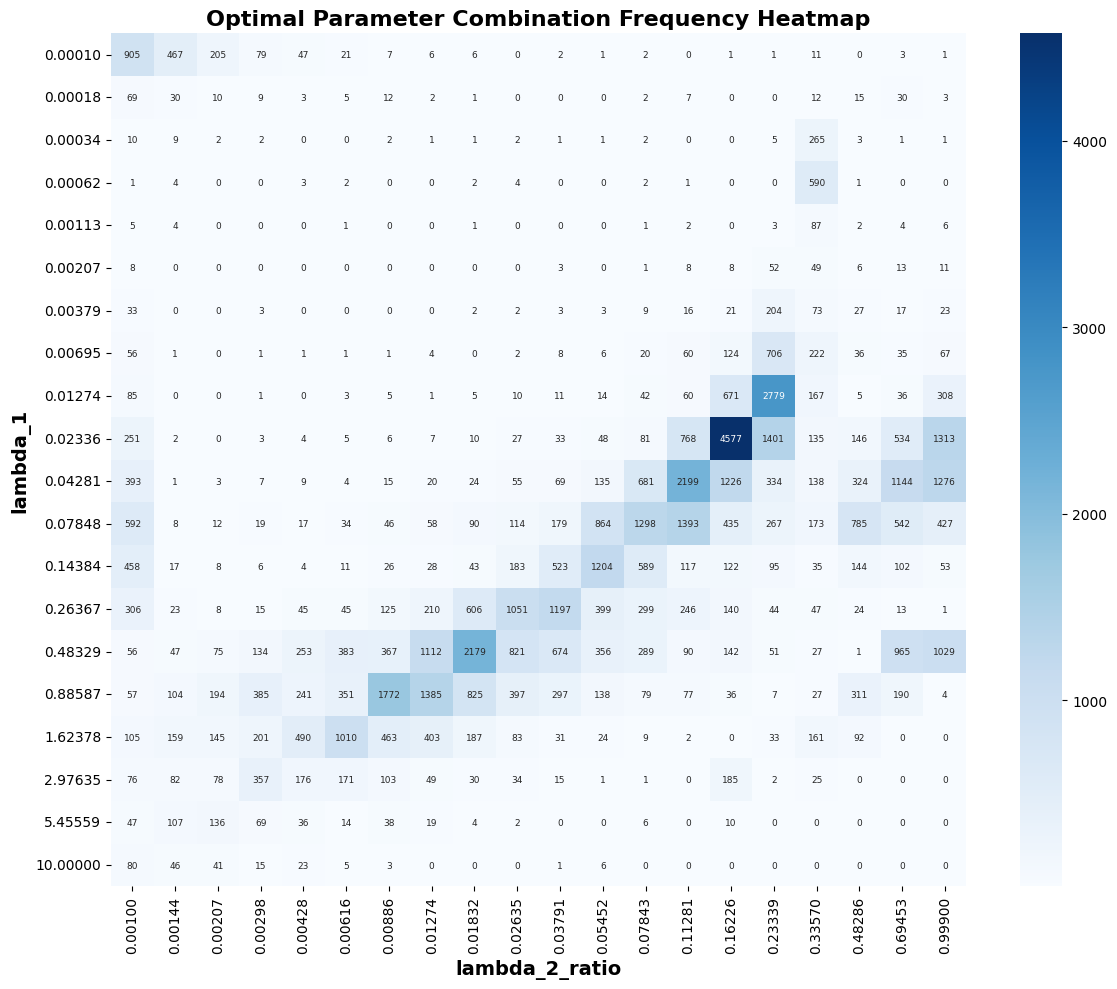

最频繁成为最优的参数组合:
  ID: lambda_combination_194
  Lambda 1: 0.023357214691
  Lambda 2 ratio: 0.162258011462
  成为最优的次数: 4577.0
  占总时间点的比例: 7.134840218238503%

前 n 个最频繁成为最优的参数组合:
 1. ID: lambda_combination_194  , Lambda 1: 0.023357214691, Lambda 2 ratio: 0.162258011462, 频数: 4577.0  , 占比: 7.13%
 2. ID: lambda_combination_175  , Lambda 1: 0.012742749857, Lambda 2 ratio: 0.233387728427, 频数: 2779.0  , 占比: 4.33%
 3. ID: lambda_combination_213  , Lambda 1: 0.042813323987, Lambda 2 ratio: 0.112806540691, 频数: 2199.0  , 占比: 3.43%
 4. ID: lambda_combination_288  , Lambda 1: 0.483293023857, Lambda 2 ratio: 0.018322087060, 频数: 2179.0  , 占比: 3.40%
 5. ID: lambda_combination_306  , Lambda 1: 0.885866790410, Lambda 2 ratio: 0.008855869472, 频数: 1772.0  , 占比: 2.76%


In [33]:
# Mean_Error_Heatmap_by_Lambda_Combinations_plot(iterative_combination_row_error, lambda_combination_dataframe)
Optimal_Parameter_Combination_Frequency_Heatmap_plot(iterative_combination_row_error, lambda_combination_dataframe)

### 1. 最优坐标
 > ##### a. 对数空间全局加权最优坐标
 > ##### b. 逐行 OLS 最优次数最多坐标

In [34]:
def compute_log_weighted_lambda(
    iterative_combination_row_error: pd.DataFrame, # 使用训练集计算全局加权最优坐标  df.iloc[:split_index] 其中 split_index 由前文交互式赋值
    lambda_combination_dataframe: pd.DataFrame,
    weight_power = 3,
    plot_bool = False
) -> dict:

    # 获取平均误差
    iterative_combination_mean_error = iterative_combination_row_error.mean(axis = 0)  # Series, index: lambda_combination_0 ~ 399
    iterative_combination_mean_error = iterative_combination_mean_error.rename('mean_error')

    # 计算指数权重 归一化
    iterative_combination_weights = np.exp(- (iterative_combination_mean_error / iterative_combination_mean_error.std()) ** weight_power) # exp(-(e/σ)²)
    iterative_combination_weights = iterative_combination_weights / np.sum(iterative_combination_weights)
    iterative_combination_weights = lambda_combination_dataframe['lambda_combination_id'].map(iterative_combination_weights.to_dict())

    # 对数空间加权平均 lambda_1
    log_lambda_1 = np.log(lambda_combination_dataframe['lambda_1']) # 将 lambda_1 映射到对数空间
    global_lambda_1 = np.exp(
        np.sum(log_lambda_1 * iterative_combination_weights))

    # 对数空间加权平均 lambda_2
    log_lambda_2 = np.log(lambda_combination_dataframe['lambda_2_ratio'] * lambda_combination_dataframe['lambda_1'])
    global_lambda_2 = np.exp(
        np.sum(iterative_combination_weights * log_lambda_2))

    if plot_bool:

        e = np.linspace(0, 3, 100)
        inverse_mapping = 1 / (1 + e)  # 倒数映射 (双曲线)
        gaussian_mapping = np.exp(-(e / 1) ** 2)  # 高斯映射

        plt.rcParams['font.family'] = ['Microsoft YaHei', 'DejaVu Sans', 'SimHei'] # 设置中文字体为黑体
        plt.rcParams['axes.unicode_minus'] = False
        plt.figure(figsize = (10, 6))
        plt.plot(e, inverse_mapping, 'b-', linewidth = 1, label = '倒数映射: 1/(1 + e)')
        plt.plot(e, gaussian_mapping, 'r-', linewidth = 1, label = '高斯映射: exp(-(e/σ)²)')
        plt.xlabel('误差 e')
        plt.ylabel('权重')
        plt.legend()
        plt.grid(True)
        plt.show()

    return {
        'global_lambda_1': global_lambda_1,
        'global_lambda_2': global_lambda_2,
    }

In [35]:
def compute_optimal_lambda_by_frequency(
    iterative_combination_row_error: pd.DataFrame, # 使用训练集计算全局加权最优坐标  df.iloc[:split_index] 其中 split_index 由前文交互式赋值
    lambda_combination_dataframe: pd.DataFrame
) -> dict:

    optimal_counts = (
        iterative_combination_row_error.idxmin(axis = 1) # axis=1 返回逐行最小值的 column
        .value_counts()) # 计算每一 lambda_combination_id 的频数，返回 pandas.core.series.Series，列名为 count

    merged_data = lambda_combination_dataframe.merge(
        optimal_counts.rename('optimal_count'),
        left_on = 'lambda_combination_id',
        right_index = True,
        how = 'left'
    ).fillna(0)
    optimal_params_row = merged_data.loc[ merged_data['optimal_count'].idxmax() ] # .idxmax 获取频数最高的行的索引，并索引出该行参数
    return {
        'optimal_lambda_1': optimal_params_row['lambda_1'],
        'optimal_lambda_2': optimal_params_row['lambda_1'] * optimal_params_row['lambda_2_ratio'],
    }

In [36]:
# 加权平均最优坐标 global_lambda_coordinates
global_lambda_coordinates = compute_log_weighted_lambda(
    iterative_combination_row_error.iloc[:split_index], # 使用训练集计算加权最优坐标 split_index 由前文交互式赋值
    lambda_combination_dataframe,
    weight_power = 23,
    plot_bool = False)

# 最优频率最优坐标 optimal_lambda_coordinates
optimal_lambda_coordinates = compute_optimal_lambda_by_frequency(
    iterative_combination_row_error.iloc[:split_index], # 使用训练集计算加权最优坐标 split_index 由前文交互式赋值
    lambda_combination_dataframe)

global_lambda_1 = global_lambda_coordinates['global_lambda_1']
global_lambda_2 = global_lambda_coordinates['global_lambda_2']

optimal_lambda_1 = optimal_lambda_coordinates['optimal_lambda_1']
optimal_lambda_2 = optimal_lambda_coordinates['optimal_lambda_2']

# 注意未来数据泄露问题 需使用训练集计算加权最优坐标 split_index 由前文交互式赋值
# iterative_combination_row_error.iloc[:split_index]
display(
    global_lambda_coordinates,
    optimal_lambda_coordinates
)

{'global_lambda_1': np.float64(0.009099831776043794),
 'global_lambda_2': np.float64(0.000225248416800737)}

{'optimal_lambda_1': np.float64(0.0233572146909012),
 'optimal_lambda_2': np.float64(0.0037898952090402362)}

### 2. 滚动窗口距离加权 lambda 序列
 > ##### a. 全局邻近加权因子
 > ##### b. 滚动窗口对数空间加权坐标

In [37]:
def compute_distance_amplification_factors(
    iterative_combination_row_error: pd.DataFrame,
    lambda_combination_dataframe: pd.DataFrame,
    global_lambda_1: float,
    global_lambda_2: float,
    amplification_exponent: float = 3.0
) -> pd.DataFrame:

    # 计算加权平均的对数坐标
    log_lambda_1_mean = np.log(global_lambda_1)
    lambda_2_mean = global_lambda_2

    # 计算每个组合的对数坐标
    log_lambda_1 = np.log(lambda_combination_dataframe['lambda_1'])
    lambda_2 = lambda_combination_dataframe['lambda_1'] * lambda_combination_dataframe['lambda_2_ratio']

    # 计算对数空间欧氏距离 sqrt((log_λ1_i - log_λ1_mean)² + (log_λ2_i - log_λ2_mean)²)
    log_distance = np.sqrt(
        (log_lambda_1 - log_lambda_1_mean) ** 2 +
        (lambda_2 - lambda_2_mean) ** 2)
    log_distance = log_distance / np.mean(log_distance)

    # 欧氏距离加权的误差指数放大
    amplification_factor = np.exp(log_distance) ** amplification_exponent
    amplification_factor = pd.Series(
        amplification_factor,
        name = 'amplification_factor'
    )

    # 确保放大因子 amplification_factors 的索引与数据框列名完全一致且顺序相同
    amplification_factor.index = lambda_combination_dataframe['lambda_combination_id']
    amplification_factor = amplification_factor.reindex(iterative_combination_row_error.columns)

    # df.mul(series, axis = 'columns')：series.index ↔ df.columns
    iterative_combination_row_error_weighted = iterative_combination_row_error.mul(amplification_factor, axis = 'columns')
    return iterative_combination_row_error_weighted

In [38]:
# iterative_combination_row_error_weighted = compute_distance_amplification_factors(
#     iterative_combination_row_error,
#     lambda_combination_dataframe,
#     global_lambda_1 = global_lambda_1,
#     global_lambda_2 = global_lambda_2,
#     amplification_exponent = 8
# )
#
# iterative_combination_row_error_weighted.head().T.head()

In [39]:
def compute_rolling_lambdas(
    main_continuous_resampled_date_index: pd.DataFrame, # 主力连续时间轴
    iterative_combination_row_error: pd.DataFrame,
    lambda_combination_dataframe: pd.DataFrame,
    window_size = 1200,
    weight_power = 3,
    plot_bool = False
) -> pd.DataFrame:

    # 预计算对数 lambda
    log_lambda_1 = np.log(lambda_combination_dataframe['lambda_1'].values)
    lambda_2 = lambda_combination_dataframe['lambda_1'] * lambda_combination_dataframe['lambda_2_ratio']

    rolling_lambda_list = []
    for current_row in range(window_size - 1, len(iterative_combination_row_error)):

        start = current_row - window_size + 1
        end = current_row + 1 # .iloc 左闭右开 终点处索引指定应该加一

        # 窗口内平均误差
        # 计算误差加权指数权重 计算归一化
        window_mean = (iterative_combination_row_error.iloc[start:end]  # .iloc 左闭右开 (left-closed, right-open) 原则
                       .mean(axis = 0)) # Series, index: lambda_combination_0 ~ 399
        weights = np.exp(- (window_mean / window_mean.std()) ** weight_power)  # (exp(-(e/σ)²))
        weights = weights / weights.sum()

        # 对数空间加权平均
        weighted_log_lambda1 = np.sum(log_lambda_1 * weights.values)
        weighted_lambda2 = np.sum(lambda_2 * weights.values)

        # 使用 end-1 来代表每个窗口最后一行的索引
        rolling_lambda_list.append({
            'index': iterative_combination_row_error.index[current_row],  # 使用实际索引
            'lambda_1': np.exp(weighted_log_lambda1),
            'lambda_2': weighted_lambda2
        })

    rolling_lambda = pd.DataFrame(rolling_lambda_list)
    rolling_lambda = rolling_lambda.set_index('index')  # 设置 index 为窗口最后一行的索引
    rolling_lambda = rolling_lambda.reindex(main_continuous_resampled_date_index.index)

    if plot_bool: # 绘制 lambda 折线图

        plt.figure(figsize = (20, 6))
        plt.plot(
            rolling_lambda.index,  # 这里直接用索引
            rolling_lambda['lambda_1'],
            'b-', label = 'λ1', linewidth = 0.8)
        plt.plot(
            rolling_lambda.index,
            rolling_lambda['lambda_2'],
            'r-', label = 'λ2', linewidth = 0.8)

        plt.ylabel('Lambda Value')
        plt.title(f'Rolling Window Weighted Average Lambdas')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return rolling_lambda

In [40]:
# rolling_lambda = compute_rolling_lambdas(
#     main_continuous_resampled_date_index,
#     iterative_combination_row_error_weighted,
#     lambda_combination_dataframe,
#     window_size = 1200,
#     weight_power = 3,
#     plot_bool = True
# )
# print(rolling_lambda.tail().values)

### 3. Nelson-Siegel-Svensson OLS 系数矩阵

In [41]:
# 主力片段拼接重采样时间索引路径 main_continuous_resampled_date_index_path
main_continuous_resampled_date_index_path = os.path.join(resample_axis_data_path, f'main_continuous_{tick_type}_date_index.csv')
main_continuous_resampled_date_index = pd.read_csv(main_continuous_resampled_date_index_path, dtype = {'date': str})

# 主力连续期限结构开盘价路径 main_continuous_curve_structure_open_timeseries_path
main_continuous_curve_structure_open_timeseries_path = os.path.join(resample_axis_data_path, r"main_continuous_curve_structure_open_timeseries.csv")
main_continuous_curve_structure_open_timeseries = pd.read_csv(main_continuous_curve_structure_open_timeseries_path, dtype ={'date': str})
# main_continuous_curve_structure_open_timeseries.info()
# print('print(main_continuous_curve_structure_open_timeseries.head())')
# print(main_continuous_curve_structure_open_timeseries.head())

# 主力连续期限结构到期时间路径 main_continuous_curve_structure_time_length_path
main_continuous_curve_structure_time_length_path = os.path.join(resample_axis_data_path, r"main_continuous_curve_structure_time_length.csv")
main_continuous_curve_structure_time_length = pd.read_csv(main_continuous_curve_structure_time_length_path, dtype ={'date': str})
# main_continuous_curve_structure_time_length.info()
# print('print(main_continuous_curve_structure_time_length.head())')
# print(main_continuous_curve_structure_time_length.head())

price_matrix = main_continuous_curve_structure_open_timeseries.drop(columns = ['date']) # 丢弃 date 列方便后续提取价格行
maturity_matrix = main_continuous_curve_structure_time_length.drop(columns = ['date']) # 丢弃 date 列方便后续提取时间行
maturity_matrix = maturity_matrix / (24 * 60)  # 将剩余到期时间从分钟转换为 天

print(f"价格矩阵 price_matrix.shape: {price_matrix.shape}")
print(f"期限矩阵 maturity_matrix.shape: {maturity_matrix.shape}")
print(f"日期范围 date range: {main_continuous_resampled_date_index.iloc[0, 0]} 到 {main_continuous_resampled_date_index.iloc[-1, 0]}")

价格矩阵 price_matrix.shape: (64150, 12)
期限矩阵 maturity_matrix.shape: (64150, 12)
日期范围 date range: 2015-01-05 09:02:00 到 2026-03-31 15:00:00


In [42]:
def compute_nelson_siegel_svensson_price_loadings(
    lambda_1: float,
    lambda_2: float,
    maturity_series: np.ndarray
) -> np.ndarray:
    """
    计算 Nelson-Siegel-Svensson 四因子模型的期货价格载荷矩阵
    compute_nelson_siegel_svensson_price_loadings:
    price_loadings 价格载荷，因子对价格的敏感度/权重

    因子载荷定义：
      L0(τ) = 1
      L1(τ) = (1 - exp(-λ₁τ)) / (λ₁τ)
      L2(τ) = L1(τ) - exp(-λ₁τ)
      L3(τ) = (1 - exp(-λ₂τ)) / (λ₂τ) - exp(-λ₂τ)

    在 τ → 0 时，使用解析极限：
      L1(0) = 1, L2(0) = 0, L3(0) = 0
    """

    # 载荷矩阵初始化 shape(len(maturity_series), 4)
    price_loadings_matrix = np.empty((len(maturity_series), 4), dtype = np.float64)
    price_loadings_matrix[:, 0] = 1.0  # 水平因子载荷，常数项，所有期限点均为 1

    # 安全阈值，判断 τ 是否接近 0
    epsilon = 1e-3
    maturity_lim_zero = maturity_series < epsilon

    # 若 τ ≈ 0 使用极限值
    if np.any(maturity_lim_zero):

        price_loadings_matrix[maturity_lim_zero, 1] = 1.0  # slope → 1
        price_loadings_matrix[maturity_lim_zero, 2] = 0.0  # curvature1 → 0
        price_loadings_matrix[maturity_lim_zero, 3] = 0.0  # curvature2 → 0

    # 若 τ > 0 按正常流程计算载荷
    if np.any(~maturity_lim_zero):

        first_decay_term = maturity_series[~maturity_lim_zero] * lambda_1  # 第一个载荷衰减参数指数项 (λ₁τ)
        second_decay_term = maturity_series[~maturity_lim_zero] * lambda_2  # 第二个载荷衰减参数指数项 (λ₂τ)

        slope_factor_loadings = (1 - np.exp(-first_decay_term)) / first_decay_term  # 斜率因子载荷 (1 - exp(-λ₁)) / (λ₁τ)
        first_curvature_factor_loadings = slope_factor_loadings - np.exp(-first_decay_term)  # 第一个曲率因子载荷 (1 - exp(-λ₁τ)) / (λ₁τ) - exp(-λ₁τ)

        second_curvature_factor_loadings = ( # 第二个曲率因子载荷 (1 - exp(-λ₂τ)) / (λ₂τ) - exp(-λ₂τ)
            ((1 - np.exp(-second_decay_term)) / second_decay_term) -
            np.exp(-second_decay_term)
        )

        price_loadings_matrix[ ~ maturity_lim_zero, 1] = slope_factor_loadings
        price_loadings_matrix[ ~ maturity_lim_zero, 2] = first_curvature_factor_loadings
        price_loadings_matrix[ ~ maturity_lim_zero, 3] = second_curvature_factor_loadings

    # 组合成完整的价格载荷矩阵
    price_loadings_matrix = pd.DataFrame(
        price_loadings_matrix, columns = ['level_factor_loadings ', 'slope_factor_loadings', 'first_curvature_factor_loadings', 'second_curvature_factor_loadings']
    )
    return price_loadings_matrix

In [43]:
def compute_single_row_NSS_OLS(
    lambda_1: float,
    lambda_2: float,
    price_vector: np.ndarray,
    maturity_vector: np.ndarray
) -> dict:
    """ 计算给定 λ 参数下单个时间点的截面数据拟合误差 """

    # 计算价格载荷矩阵
    price_loadings_matrix = compute_nelson_siegel_svensson_price_loadings(
        lambda_1 = lambda_1,
        lambda_2 = lambda_2,
        maturity_series = maturity_vector
    )

    try:
        # beta_factors = np.linalg.pinv(  # 使用伪逆最小二乘最小二乘法拟合 β 因子
        #     price_loadings_matrix, # 解释变量、自变量矩阵、即因子载荷
        # ) @ price_vector # 被解释变量、因变量列
        beta_factors, residuals, _, _ = np.linalg.lstsq(  # 使用最小二乘法拟合 β 因子
            price_loadings_matrix, # 自变量矩阵、即因子载荷
            price_vector, # 因变量列
            rcond = None
        )
        # fitted_prices = price_loadings_matrix @ beta_factors  # 计算拟合价格
        # error = np.mean((price_vector - fitted_prices) ** 2)  # 计算均方误差
    except np.linalg.LinAlgError: beta_factors = residuals = None
    return {
        'beta_factors': beta_factors,
        'residuals': residuals
    }

In [44]:
log_weighted_lambda_bool = False # 对数空间加权 lambda
optimal_lambda_by_frequency_bool = True # 最优频数 lambda 坐标

In [45]:
# rolling_lambda_NaN_mask = ~ rolling_lambda.isnull().all(axis = 1)  # rolling_lambda 的首个窗口产生 len(window) 个空值行
# price_matrix_NaN_mask = ~ price_matrix.isnull().all(axis = 1)
# maturity_matrix_NaN_mask = ~ maturity_matrix.isnull().all(axis = 1)
#
# NaN_mask = price_matrix_NaN_mask & maturity_matrix_NaN_mask # & rolling_lambda_NaN_mask
# index_range = main_continuous_resampled_date_index.index[NaN_mask]

lambda_1 = optimal_lambda_coordinates['optimal_lambda_1']
lambda_2 = optimal_lambda_coordinates['optimal_lambda_2']

NSS_factors_list = []
index_range = main_continuous_resampled_date_index.index
for current_index in index_range.to_list():

    price_vector = price_matrix.iloc[current_index].values
    maturity_vector = maturity_matrix.iloc[current_index].values

    single_row_NSS_OLS_dict = compute_single_row_NSS_OLS(
        lambda_1 = lambda_1,
        lambda_2 = lambda_2,
        price_vector = price_vector,
        maturity_vector = maturity_vector
    )
    beta_0, beta_1, beta_2, beta_3 = single_row_NSS_OLS_dict['beta_factors']
    residuals = single_row_NSS_OLS_dict['residuals'][0]
    NSS_factors_list.append({
        'lambda_1': lambda_1,
        'lambda_2': lambda_2,
        'beta_0': beta_0,
        'beta_1': beta_1,
        'beta_2': beta_2,
        'beta_3': beta_3,
        'residuals': residuals
    })

NSS_factors = pd.DataFrame(NSS_factors_list)
NSS_factors.head()

,lambda_1,lambda_2,beta_0,beta_1,beta_2,beta_3,residuals
0,0.023357,0.00379,330.826553,2172.425415,1598.836542,6277.488300,2603.721907
1,0.023357,0.00379,1717.197630,834.629751,518.913947,2466.271301,5200.663810
2,0.023357,0.00379,1734.203259,819.994248,529.381961,2438.557617,4472.407444
3,0.023357,0.00379,2331.713229,242.097131,35.079425,801.435301,2067.430744
4,0.023357,0.00379,2646.772308,-68.788449,-178.920298,-95.777306,2105.984598


In [46]:
import gc; gc.collect()
# 期限结构拟合文件路径 Nelson_Siegel_Svensson_path
Nelson_Siegel_Svensson_path = os.path.join(resample_axis_data_path, f'Nelson_Siegel_Svensson')

# NSS 四因子模型参数路径 NSS_factors_path
NSS_factors_path = os.path.join(Nelson_Siegel_Svensson_path, f'NSS_factors.csv')
NSS_factors.to_csv(NSS_factors_path, index = False)

#### 4. 期限结构曲面绘制

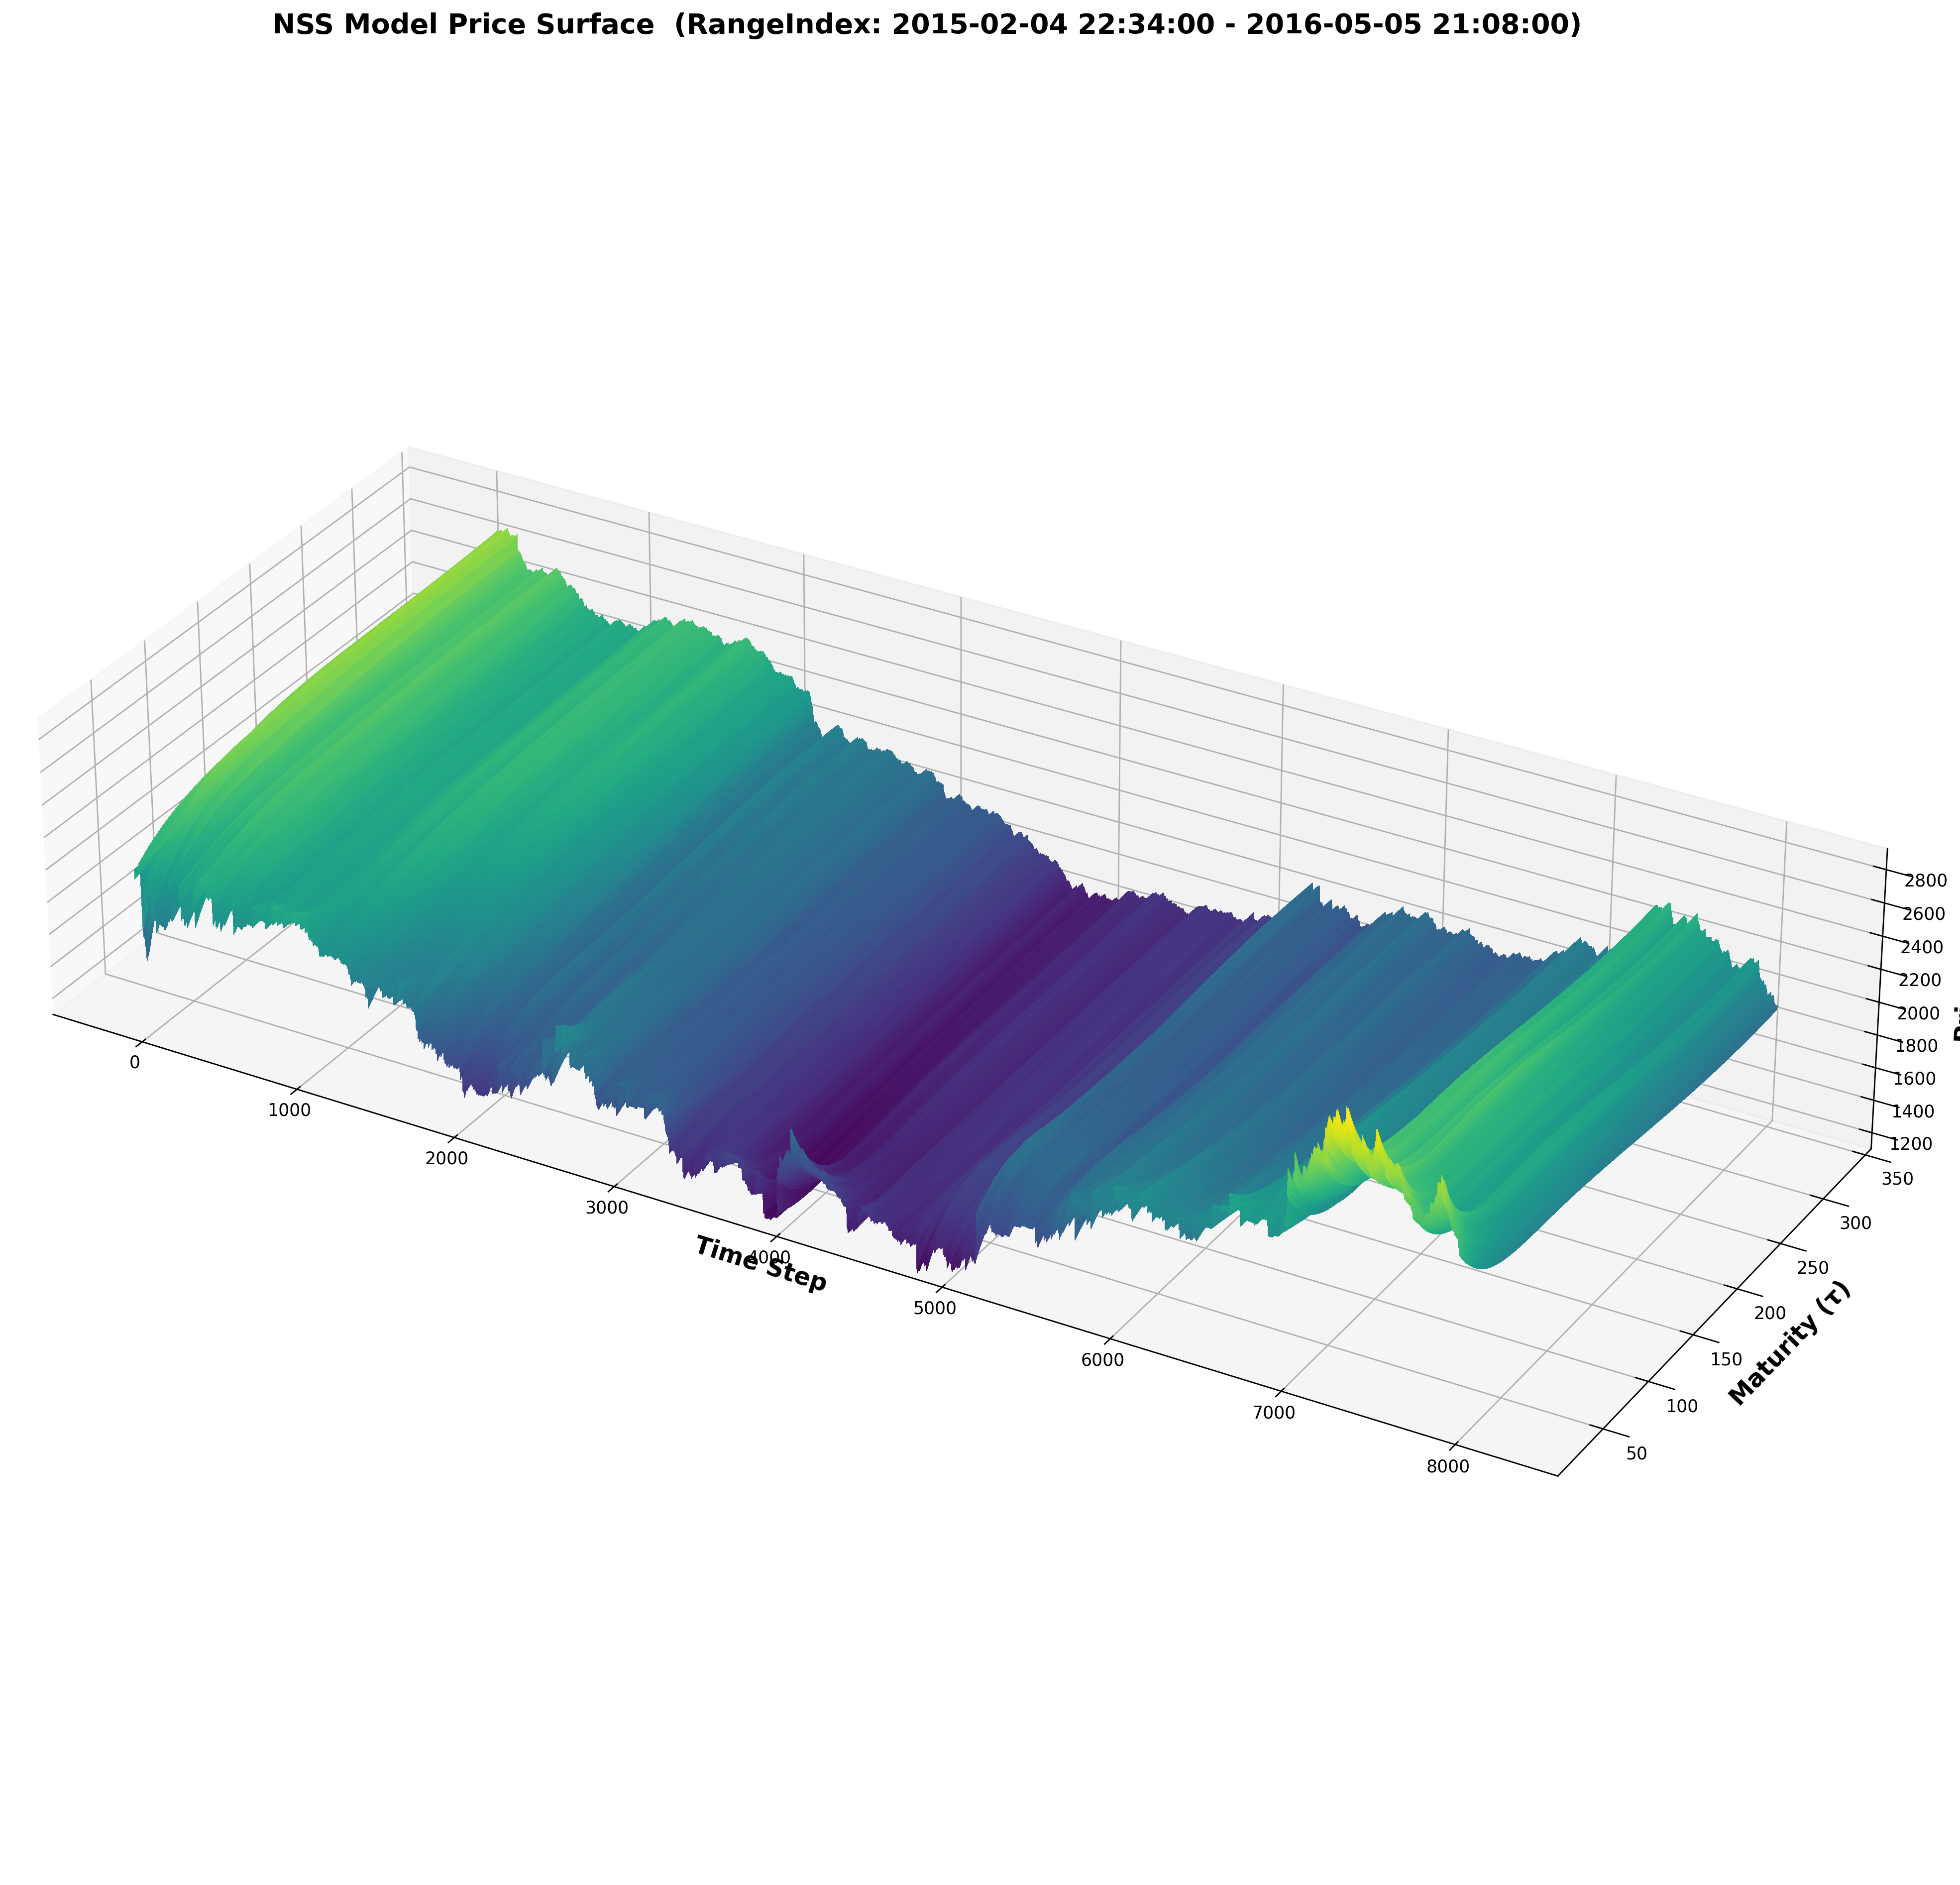

2389263

In [90]:
def NSS_Model_Price_Surface_plot(slice_start, slice_end):

    slice_start = slice_start  # 起始索引
    slice_end = slice_end   # 结束索引
    # slice_step = int((slice_end - slice_start) / 1000)
    NSS_factors_subset = NSS_factors.iloc[
        slice_start : slice_end :
        # slice_step
    ]

    lambda_1 = optimal_lambda_coordinates['optimal_lambda_1']
    lambda_2 = optimal_lambda_coordinates['optimal_lambda_2']

    tau_granuality = 150  # 期限方向采样点颗粒度
    tau_length = 372 - 15   # 期限计算长度
    tau_step_index = np.linspace(1, tau_length, tau_granuality)  # 三维曲面绘制的 tao 期限方向线性等距采样索引
    time_step_index = np.arange(len(NSS_factors_subset))  #  三维曲面绘制的 date 时间步方向线性等距采样索引


    # 初始化价格矩阵 shape (index = RangeIndex(len(time_step_index)), columns = RangeIndex(len(tau_step_index)))
    NSS_price_matrix = np.zeros((len(time_step_index), len(tau_step_index)))

    for i in range(len(NSS_factors_subset)):
        row = NSS_factors_subset.iloc[i]
        beta = np.array([row['beta_0'], row['beta_1'], row['beta_2'], row['beta_3']])

        # 计算载荷矩阵 (n_tau, 4)
        price_loadings_matrix = compute_nelson_siegel_svensson_price_loadings(
            lambda_1 = lambda_1,
            lambda_2 = lambda_2,
            maturity_series = tau_step_index
        )
        # 计算价格：P(τ) = β₀·L₀ + β₁·L₁ + β₂·L₂ + β₃·L₃
        NSS_price_matrix[i, :] = price_loadings_matrix.values @ beta

    # 转为网格用于绘图
    time_step_matrix, tau_step_matrix = np.meshgrid(time_step_index, tau_step_index, indexing = 'ij')  # T.shape = (time_step_index, tau_step_index)



    fig = plt.figure(figsize = (15, 16), dpi = 250)
    ax = fig.add_subplot(111, projection = '3d')

    ax.plot_surface(
        X = time_step_matrix,
        Y = tau_step_matrix,
        Z = NSS_price_matrix,
        cmap = 'viridis',
        rstride = 1,  # 行步长，控制绘制的网格线的密度，值为 1 表示每行都绘制
        cstride = 1,  # 列步长，控制绘制的网格线的密度，值为 1 表示每列都绘制
        shade = True, # 布尔值，是否进行光照着色，使表面看起来有立体感
        edgecolors = 'none',  # 网格线绘制的样式
        antialiased = False,  # 布尔值，是否启用抗锯齿，使表面边缘更平滑
    )

    ax.set_box_aspect([5, 2, 1])  # 设置坐标轴比例 x:y:z
    y_min, y_max = tau_step_matrix.min(), tau_step_matrix.max()
    # x_min, x_max = (
    #     time_step_matrix.min() - len(time_step_matrix) * 0.01,
    #     time_step_matrix.max() + len(time_step_matrix) * 0.01)
    ax.set_ylim(y_min, y_max)
    # ax.set_xlim(x_min, x_max)

    slice_start_date_point = main_continuous_resampled_date_index.iloc[slice_start]['date']
    slice_end_date_point = main_continuous_resampled_date_index.iloc[slice_end]['date']
    ax.set_title(f'NSS Model Price Surface  (RangeIndex: {slice_start_date_point} - {slice_end_date_point})', fontsize = 16, fontweight ='bold')
    ax.set_xlabel('Time Step', fontsize = 14, fontweight = 'bold')
    ax.set_ylabel('Maturity (τ)', fontsize = 14, fontweight = 'bold')
    ax.set_zlabel('Price', fontsize = 14, fontweight = 'bold')

    plt.tight_layout()
    plt.show()



slice_start = 500
NSS_Model_Price_Surface_plot(slice_start = slice_start, slice_end = slice_start + 8000)
import gc; gc.collect()

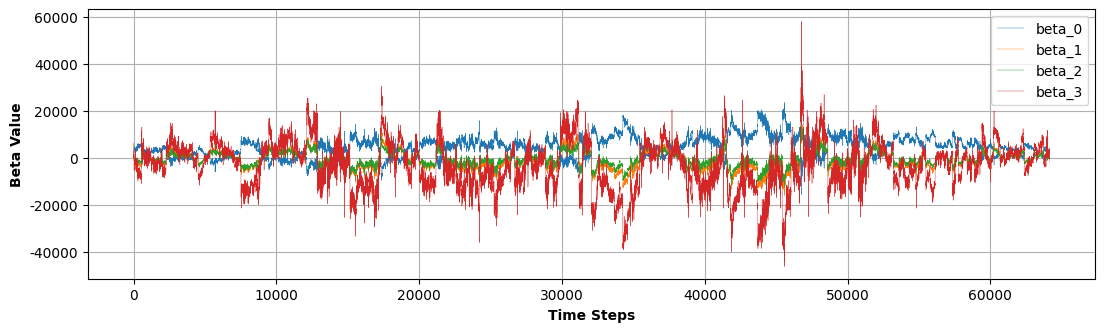

4438

In [32]:
def NSS_factors_plot_01():

    plt.figure(figsize = (13, 3.5))
    for beta_column in ['beta_0', 'beta_1', 'beta_2', 'beta_3']:
        plt.plot(
            NSS_factors.index.values,
            NSS_factors[beta_column],
            lw = 0.3,
            label = beta_column
        )

    # plt.title('Beta Values', fontsize = 14, fontweight = 'bold')
    plt.xlabel('Time Steps', fontsize = 10, fontweight = 'bold')
    plt.ylabel('Beta Value', fontsize = 10, fontweight = 'bold')
    plt.legend()
    plt.grid(True)
    plt.show()

NSS_factors_plot_01()
import gc; gc.collect()

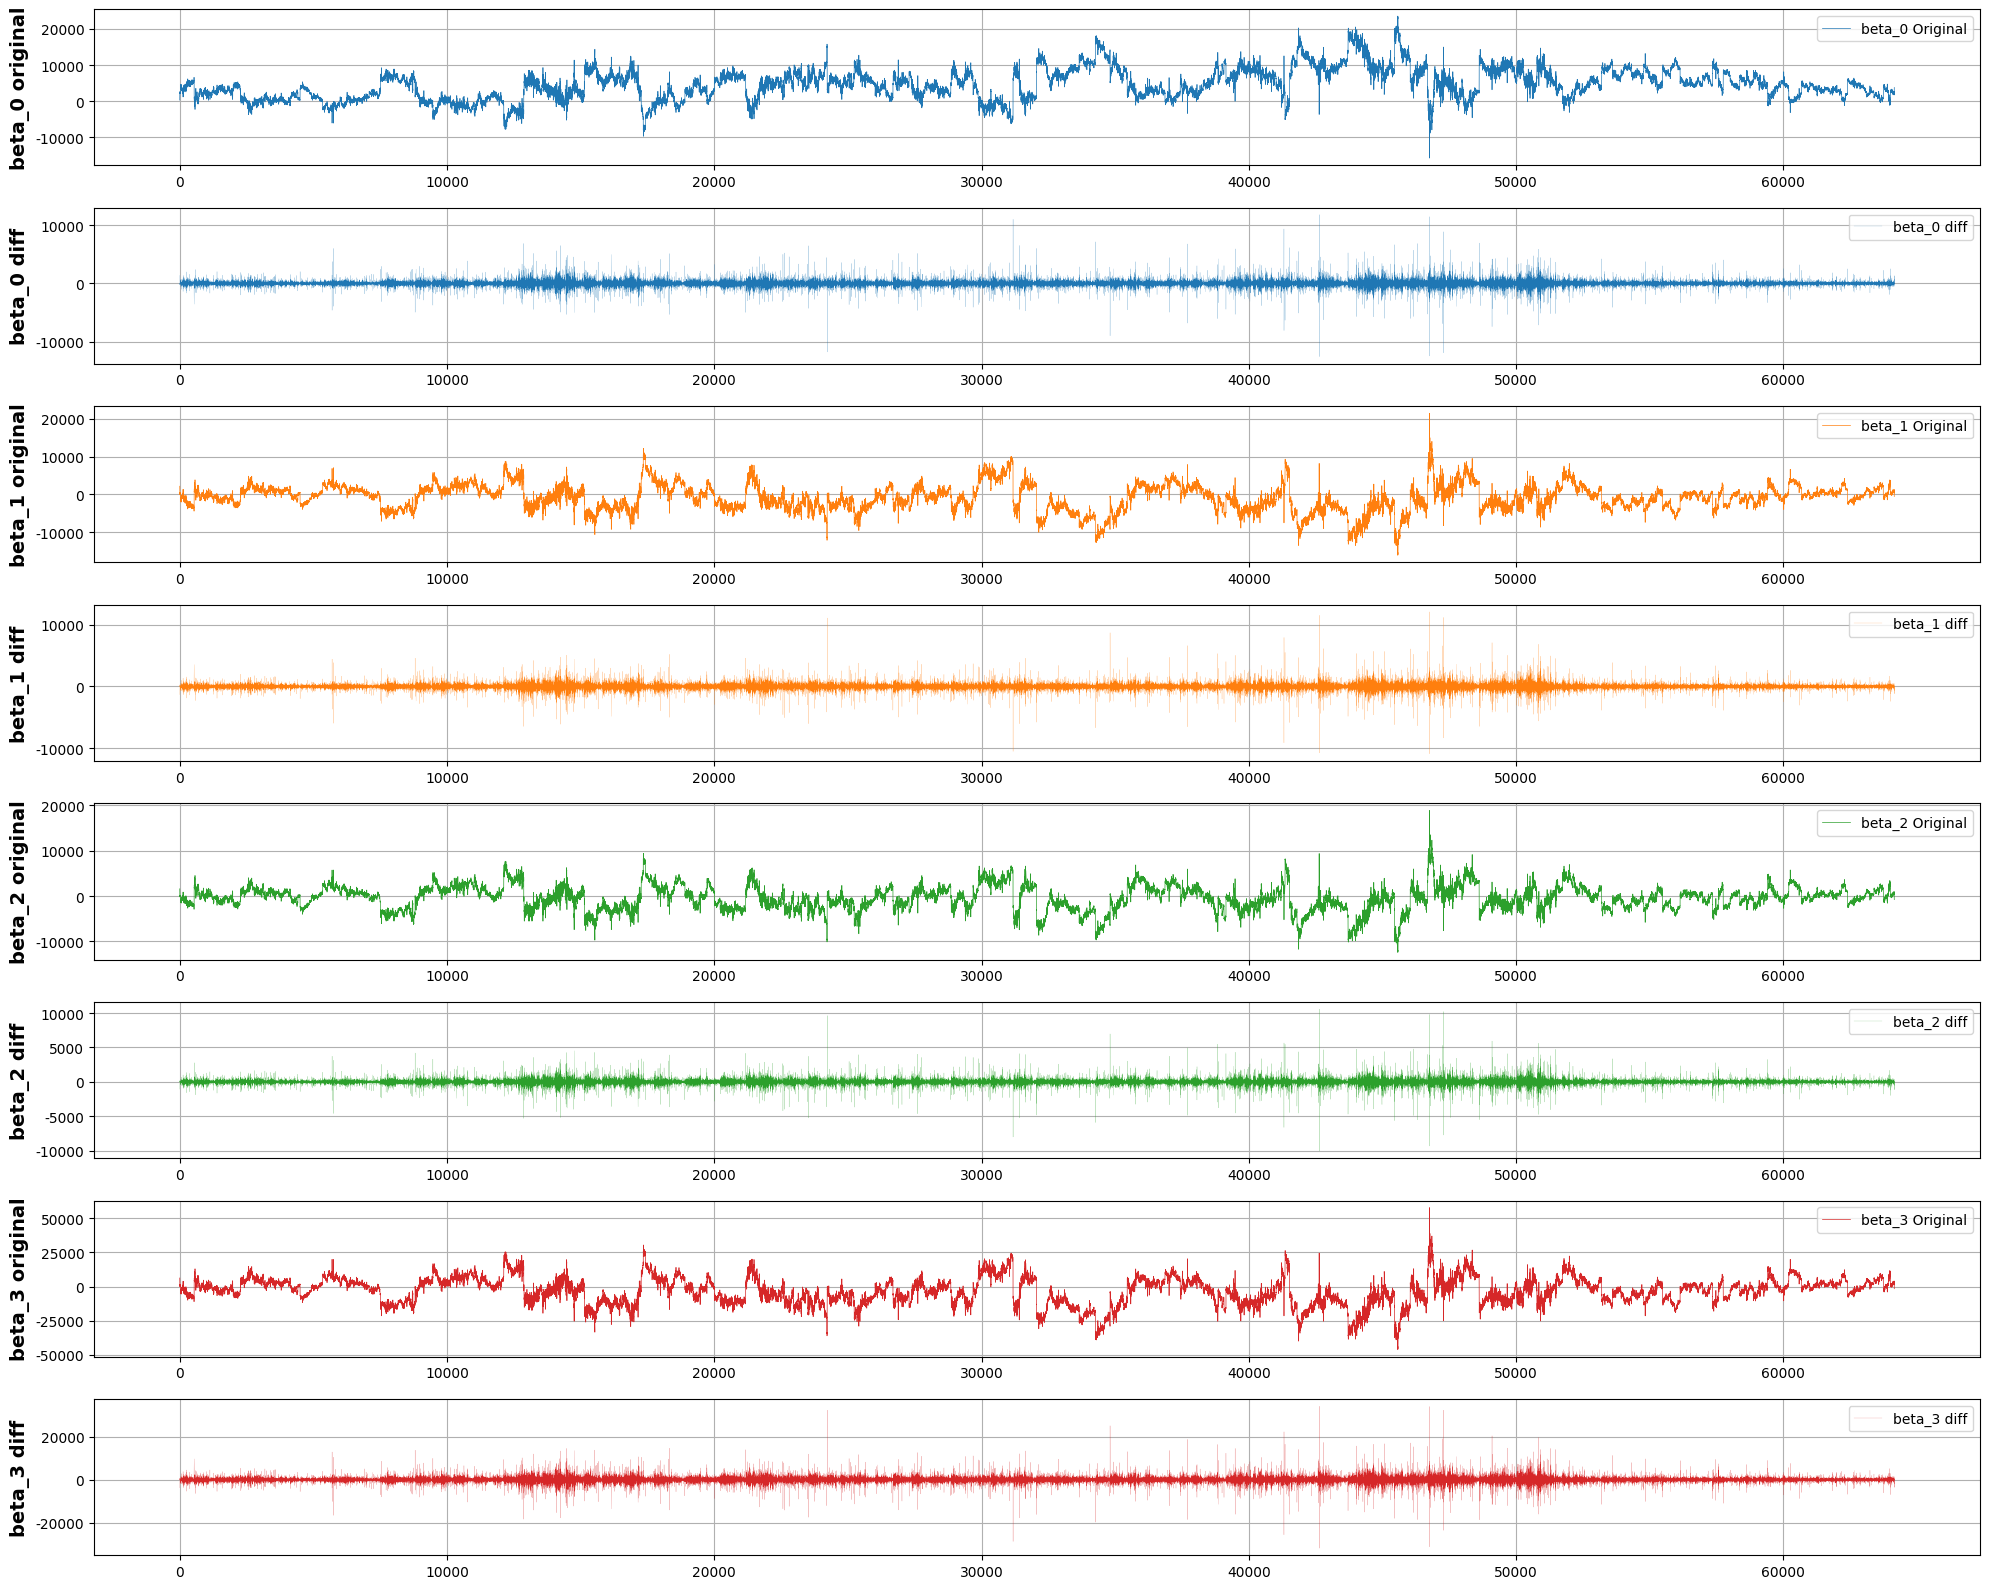

26823

In [83]:
def NSS_factors_plot_02():

    fig, axes = plt.subplots(8, 1, figsize = (20, 2 * 8))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:4]

    for index, beta_column in enumerate(['beta_0', 'beta_1', 'beta_2', 'beta_3']):
        # 原始序列的子图
        ax_original = axes[index * 2]   # 偶数索引位置放置原始序列
        ax_original.plot(
            NSS_factors.index.values,
            NSS_factors[beta_column],
            lw = 0.5,  # 增加线宽以便于区分
            label = beta_column + ' Original',
            color = colors[index]
        )
        ax_original.set_ylabel(f'{beta_column} original', fontsize = 14, fontweight = 'bold')
        ax_original.legend()
        ax_original.grid(True)

        # 差分序列的子图
        ax_diff = axes[index * 2 + 1]  # 奇数索引位置放置差分序列
        ax_diff.plot(
            NSS_factors.index.values,
            NSS_factors[beta_column].diff(),
            lw = 0.1,
            label = beta_column + ' diff',
            color = colors[index]
        )
        ax_diff.set_ylabel(f'{beta_column} diff', fontsize = 14, fontweight = 'bold')
        ax_diff.legend()
        ax_diff.grid(True)

    plt.tight_layout()
    plt.show()


NSS_factors_plot_02()
import gc; gc.collect()

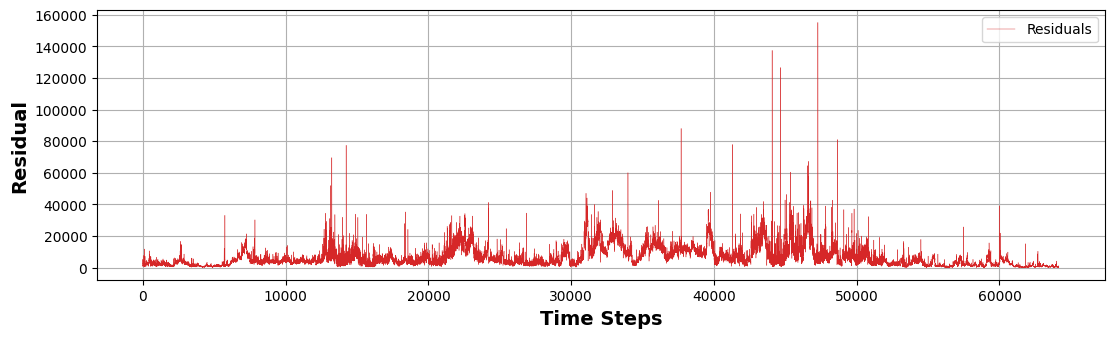

4248

In [31]:
plt.figure(figsize = (13, 3.5))
plt.plot(NSS_factors.index, NSS_factors['residuals'], label = 'Residuals', lw = 0.3, color = 'tab:red')

plt.xlabel('Time Steps', fontsize = 14, fontweight = 'bold')
plt.ylabel('Residual', fontsize = 14, fontweight = 'bold')
plt.legend()
plt.grid(True)
plt.show()

import gc; gc.collect()

In [89]:
def NSS_specific_time_point(index = 10000, save_path = None):

    index = index
    slice_start_date_point = main_continuous_resampled_date_index.iloc[index]['date']

    price_series = price_matrix.iloc[index].values  # 真实价格序列
    maturity_series = maturity_matrix.iloc[index].values # 真实期限序列

    tau_granularity = 360  # 采样点数量
    tau_length = 372       # 最大期限
    tau_grid = np.linspace(0, tau_length, tau_granularity)
    dense_loadings_matrix = compute_nelson_siegel_svensson_price_loadings(
        lambda_1 = lambda_1,
        lambda_2 = lambda_2,
        maturity_series = tau_grid  # 使用密集网格
    )

    row = NSS_factors.iloc[index]
    beta = np.array([row['beta_0'], row['beta_1'], row['beta_2'], row['beta_3']])
    fitted_prices_dense = dense_loadings_matrix.values @ beta



    plt.figure(figsize = (13, 5))
    plt.plot(tau_grid, fitted_prices_dense, label = 'Nelson-Siegel-Svensson', color = 'tab:blue', linewidth = 0.5)
    plt.scatter(maturity_series, price_series, color = 'tab:red', label = 'Actual Prices', zorder = 5)

    fitted_at_actual_tau = np.interp(maturity_series, tau_grid, fitted_prices_dense) # 对每个真实期限，插值得到 NSS 拟合价格
    for i in range(len(maturity_series)):  # 垂直虚线，从实际点到曲线
        plt.plot(
            [maturity_series[i], maturity_series[i]],
            [price_series[i], fitted_at_actual_tau[i]],
            color = 'gray',
            linestyle = '--',
            linewidth = 0.8,)

    plt.title(f'NSS - Actual Prices at {slice_start_date_point}', fontsize = 14, fontweight ='bold')
    plt.xlabel('Maturity (τ)', fontsize = 10, fontweight = 'bold')
    plt.ylabel('Price', fontsize = 10, fontweight = 'bold')
    plt.legend()
    plt.grid(True)

    if save_path is not None: plt.savefig(save_path); plt.close()
    else: plt.show()



save_path = None
for num in range(13000, 14000, 5):
    specific_time_point_index = num
    save_path = rf"C:\Users\31918\Desktop\tmp_png_viwer\{specific_time_point_index}.png"
    NSS_specific_time_point(
        index = specific_time_point_index,
        save_path = save_path
    )

# NSS_specific_time_point(
#     index = 34300,
#     save_path = None)
import gc; gc.collect()

932